In [ ]:
import numpy as np

# ============================================================
# Parameters
# ============================================================

class Params:
    def __init__(self):
        self.m = 1.0
        self.g = 9.81
        self.dt = 1e-3
        self.mu = 0.5
        self.e = 0.0
        self.T = 1.0

        self.q0 = np.array([0., 0., 1.0])
        self.xy_target = np.array([1.0, 0.5])
        self.z_target = 0.0


# ============================================================
# Prox operators (Coulomb cone)
# ============================================================

def prox_normal(p_N):
    return max(p_N, 0.0)

def prox_friction_disk(p_T, p_N, mu):
    max_norm = mu * max(p_N, 0.0)
    nrm = np.linalg.norm(p_T)
    if nrm <= max_norm:
        return p_T
    if nrm == 0.0:
        return np.zeros_like(p_T)
    return p_T * (max_norm / nrm)

def prox_contact(p, mu):
    """
    p = [p_Tx, p_Ty, p_N]
    """
    p_T = p[:2]
    p_N = p[2]

    p_N_proj = prox_normal(p_N)
    p_T_proj = prox_friction_disk(p_T, p_N_proj, mu)

    return np.array([p_T_proj[0], p_T_proj[1], p_N_proj])


# ============================================================
# Contact solver (Gauss–Seidel)
# ============================================================

def solve_contact_GS(G, c, mu, max_iter=20):
    """
    Solve p = prox( p - r (Gp + c) )
    for p = [p_Tx, p_Ty, p_N]
    """
    
    # Eq. (11): initialize with -G_jj^{-1} c_j
    # For one contact, G itself is the local block G_jj.
    try:
        p = -np.linalg.solve(G, c)
    except np.linalg.LinAlgError:
        # safer fallback if G is poorly conditioned
        p = -np.linalg.pinv(G) @ c

    abs_G_sum = np.sum(np.abs(G))
    r = 1.0 / (1.0 + abs_G_sum)

    for _ in range(max_iter):
        s = G @ p
        p_new = p - r * (s + c)
        p = prox_contact(p_new, mu)

    return p


# ============================================================
# One Moreau time step
# ============================================================

def moreau_step(q_S, v_S, params):
    m = params.m
    g = params.g
    dt = params.dt
    mu = params.mu

    # First semi-step
    q_M = q_S + 0.5 * dt * v_S

    # Contact detection (plane z=0)
    if q_M[2] > 0.0:
        # No contact → free flight
        v_E = v_S + dt * np.array([0, 0, -g])
        q_E = q_M + 0.5 * dt * v_E
        return q_E, v_E, np.zeros(3)

    # Contact active
    H_inv = (1/m) * np.eye(3)

    # NORMAL Jacobian (1×3)
    J_n = np.array([[0., 0., 1.]])   # only constraint

    # TANGENTIAL basis (not constraints)
    T1 = np.array([1., 0., 0.])   # x tangent
    T2 = np.array([0., 1., 0.])   # y tangent

    # Build G in contact coordinates:
    # We need relative velocity in local contact frame.
    # First compute normal part:
    G_nn = J_n @ H_inv @ J_n.T           # scalar 1×1

    # Tangential parts:
    G_T1 = T1 @ H_inv @ T1.T             # scalar for Tx
    G_T2 = T2 @ H_inv @ T2.T             # scalar for Ty

    # Assemble full 3×3 G:
    # Tangential directions are orthogonal in point-mass case
    G = np.diag([G_T1, G_T2, G_nn.item()])   # 3×3 diagonal

    # Free motion in each contact direction
    g_forces = np.array([0., 0., -m*g])
    v_free = v_S + dt * (H_inv @ g_forces)

    v_T_free = np.array([v_free[0], v_free[1]])
    v_N_free = v_free[2]

    # c = "free" velocities in contact frame
    gamma_S = np.array([v_S[0], v_S[1], v_S[2]])  # current contact velocities
    c = np.array([v_T_free[0], v_T_free[1], v_N_free]) + params.e * gamma_S 

    # Solve impulses
    p = solve_contact_GS(G, c, mu)

    # Update velocity
    v_E = v_free.copy()
    v_E[0] += p[0] / m
    v_E[1] += p[1] / m
    v_E[2] += p[2] / m

    # Second semi-step
    q_E = q_M + 0.5 * dt * v_E

    return q_E, v_E, p


# ============================================================
# Trajectory simulation
# ============================================================

def init_state(theta, params, sigma=0.1):
    w = np.random.randn(2) * sigma
    q0 = params.q0.copy()
    v0 = np.array([theta[0] + w[0],
                   theta[1] + w[1],
                   0.0])
    return q0, v0, w

def simulate(theta, params, sigma=0.1):
    q, v, w = init_state(theta, params, sigma)
    dt = params.dt
    N = int(params.T / dt)

    traj_q = np.zeros((N+1,3))
    traj_v = np.zeros((N+1,3))
    traj_p = np.zeros((N,3))

    traj_q[0] = q
    traj_v[0] = v

    for k in range(N):
        q, v, p = moreau_step(q, v, params)
        traj_q[k+1] = q
        traj_v[k+1] = v
        traj_p[k] = p

    return traj_q, traj_v, traj_p, w


# ============================================================
# Loss
# ============================================================

def loss_and_noise(theta, params, sigma=0.1):
    traj_q, traj_v, traj_p, w = simulate(theta, params, sigma)
    q_T = traj_q[-1]

    diff_xy = q_T[:2] - params.xy_target
    diff_z  = q_T[2] - params.z_target

    L = diff_xy @ diff_xy + diff_z**2
    return float(L), w, traj_q, traj_v, traj_p


# ============================================================
# Quick test
# ============================================================

if __name__ == "__main__":
    params = Params()
    theta = np.array([10.0, 5.0])  # only horizontal initial velocity
    sigma = 0.1 # noise std

    L, w, traj_q, traj_v, traj_p = loss_and_noise(theta, params, sigma)
    print("Loss(theta) =", L)
    print("Noise w =", w)

    print("Final state q_T:", traj_q[-1])
    print("Final velocity v_T:", traj_v[-1])
    print("Impulses:\n", traj_p[-550:])


Loss(theta) = 65.62067636250104
Noise w = [ 0.07011087 -0.1692398 ]
Final state q_T: [ 8.31164104e+00  3.98719987e+00 -4.32818000e-03]
Final velocity v_T: [5.64764474 2.70924698 0.        ]
Impulses:
 [[ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [-2.00337716e+00 -9.61045490e-01  4.44393000e+00]
 ...
 [-4.42246613e-03 -2.12151322e-03  9.81000000e-03]
 [-4.42246613e-03 -2.12151322e-03  9.81000000e-03]
 [-4.42246613e-03 -2.12151322e-03  9.81000000e-03]]


In [ ]:
# if the point is below ground than each time contact detection gives small impulses, biggest one is in z
# coordinate and the first one (when touches the ground)

In [6]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.animation as animation
from IPython.display import Image, display
import numpy as np

def animate_3D(traj_q, filename="animation.gif", interval=15):
    """
    3D animation of the point mass trajectory.
    Saves a GIF using PillowWriter and displays it inside VS Code notebooks.
    """

    x = traj_q[:,0]
    y = traj_q[:,1]
    z = traj_q[:,2]

    # Create figure
    fig = plt.figure(figsize=(7,6))
    ax = fig.add_subplot(111, projection="3d")

    # Axis limits
    ax.set_xlim(np.min(x)-0.5, np.max(x)+0.5)
    ax.set_ylim(np.min(y)-0.5, np.max(y)+0.5)
    ax.set_zlim(0, max(1.0, np.max(z)+0.5))

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    ax.set_title("3D ball trajectory")

    # Static path
    ax.plot(x, y, z, color="lightgray", linewidth=1)

    # Moving point
    point, = ax.plot([x[0]], [y[0]], [z[0]],
                     marker="o", markersize=7, color="red")

    # Update function
    def update(i):
        point.set_data([x[i]], [y[i]])
        point.set_3d_properties([z[i]])
        return point,

    # Build animation object
    ani = animation.FuncAnimation(
        fig,
        update,
        frames=len(traj_q),
        interval=interval,
        blit=True
    )

    # Save as GIF via PillowWriter (NO FFMPEG)
    ani.save(filename, writer="pillow", fps=int(1000/interval))

    plt.close(fig)  # prevent static image output

    # Display the GIF inline
    display(Image(filename=filename))


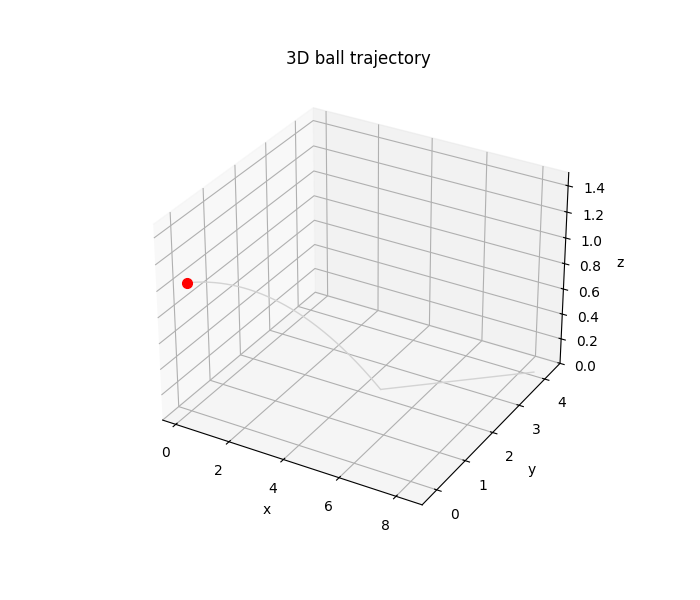

In [7]:
traj_q, traj_v, traj_p, _ = simulate(theta, params)
animate_3D(traj_q)